# DS2002 - Midterm Project
## Group Members - Arjun Ramakrishnan, Kevin Teng, Inmar Chavarria-Ramirez

## Basic Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
from datetime import datetime, timedelta
from dateutil import parser

## Section 1 - Data Loading and Cleaning

In [2]:
#Load Data
transactions = pd.read_csv('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/walmart_transactions.csv')
stores = pd.read_csv('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/store_locations.csv')
products = pd.read_csv('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/product_catalog.csv')
dist_centers = pd.read_csv('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/distribution_centers.csv')

# Load database data
conn_sqlite = sqlite3.connect('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/inventory_and_sales.db')
daily_sales = pd.read_sql_query("SELECT * FROM daily_sales_summary", conn_sqlite)
inventory_levels = pd.read_sql_query("SELECT * FROM inventory_levels", conn_sqlite)
conn_sqlite.close()

### Transactions Table Cleaning

#### Before Cleaning View of the Data

In [3]:
# Dimensions, rows and missing values
print("transactions shape:", transactions.shape)
display(transactions.head(10))
print(transactions.isnull().sum())

transactions shape: (25562, 8)


,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price
0,TXN012636,FL-710,2024-09-13T09:48:13,PNUTBTR-16,PEANUT BUTTER,Grocery,1,3.15
1,TXN000759,fl-412,2024-09-02 20:30:20,CNSOUP-01,CANNED SOUP,GROCERY,1,2.02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,Household Essentials,2,10.47
3,TXN025020,FL-330,2024-09-30 06:29:08,ROKU-STD,Roku Streaming Stick,ELECTRONICS,1,28.59
4,TXN015797,FL-302,2024-09-15 15:59:42,BEER-24,Light Beer 24pk,Alcoholic Beverages,3,18.82
5,TXN010403,FL-445,2024-09-12 10:32:34,CHIPVARIETY,Chips Variety Pack,snacks,1,8.75
6,TXN014974,FL_105,09/15/2024 09:26,TARP-HD,TARP - HEAVY DUTY,Emergency,2,19.48
7,TXN008161,FL-330,09/11/2024 14:47,PAPERTOWEL6,PAPER TOWELS 6PK,Household,2,7.94
8,TXN023517,FL-619,2024-09-27 16:40:14,ROKU-STD,Roku Streaming Stick,electronics,1,30.64
9,TXN012652,FL-710,09/13/2024 20:03,CANDLE-EMRG,Emergency Candles,EMERGENCY,3,5.95


transaction_id      0
store_id            0
timestamp         886
sku                 0
product_name        0
category            0
quantity            0
unit_price          0
dtype: int64


#### Cleaning

In [4]:
transactions.columns = (
    transactions.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

transactions.replace(["NULL", "N/A", ""], np.nan, inplace=True)

transactions = transactions.drop_duplicates(subset="transaction_id")

transactions["store_id"] = (
    transactions["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Enforce a consistent store_id format - "FL" followed by a hyphen and a 3 digit number
transactions["store_id"] = transactions["store_id"].str.replace(
    r"^FL[-]?(\d{3})$", r"FL-\1", regex=True
)

transactions["sku"] = (
    transactions["sku"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

transactions["product_name"] = (
    transactions["product_name"]
    .astype(str)
    .str.strip()
    .str.title()
)

transactions["category"] = (
    transactions["category"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Standardize redundant category names
category_map = {
    "Breakfast Foods": "Breakfast",
    "Groceries": "Grocery",
    "Emergency Supplies": "Emergency",
    "Alcoholic Beverages": "Alcohol",
    "Household Essentials" : "Household",
    "Baby Products" : "Baby",
    "Health & Wellness": "Health",
    "Games & Entertainment" : "Entertainment"
}
transactions["category"] = transactions["category"].replace(category_map)

# Clean timestamp strings
transactions["timestamp"] = (
    transactions["timestamp"]
    .astype(str)
    .str.strip()
    .str.replace("T", " ", regex=False)
)

# Ensure all the different timestamps are dealt with as best as possible
def safe_parse(x):
    try:
        return parser.parse(x)
    except:
        return pd.NaT

transactions["timestamp"] = transactions["timestamp"].apply(safe_parse)

# Drop invalid timestamps
transactions = transactions.dropna(subset=["timestamp"])

transactions["quantity"] = pd.to_numeric(
    transactions["quantity"],
    errors="coerce"
)

transactions = transactions.dropna(subset=["quantity"])

# Fix negative quantity errors
transactions.loc[transactions["quantity"] < 0, "quantity"] = np.nan
transactions = transactions.dropna(subset=["quantity"])
transactions["quantity"] = transactions["quantity"].astype(int)

# Clean unit_price values - remove dollar sign
transactions["unit_price"] = (
    transactions["unit_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

transactions["unit_price"] = pd.to_numeric(
    transactions["unit_price"],
    errors="coerce"
)

transactions = transactions.dropna(subset=["unit_price"])

# Extract date for daily analysis
transactions["date"] = transactions["timestamp"].dt.floor("D")

transactions = transactions.reset_index(drop=True)

#### After Cleaning View of the Data

In [5]:
# Dimensions, rows and missing values
print("transactions shape:", transactions.shape)
display(transactions.head(10))
print(transactions.isnull().sum())

transactions shape: (24521, 9)


,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price,date
0,TXN012636,FL-710,2024-09-13 09:48:13,PNUTBTR-16,Peanut Butter,Grocery,1,3.15,2024-09-13
1,TXN000759,FL-412,2024-09-02 20:30:20,CNSOUP-01,Canned Soup,Grocery,1,2.02,2024-09-02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,Household,2,10.47,2024-09-06
3,TXN025020,FL-330,2024-09-30 06:29:08,ROKU-STD,Roku Streaming Stick,Electronics,1,28.59,2024-09-30
4,TXN015797,FL-302,2024-09-15 15:59:42,BEER-24,Light Beer 24Pk,Alcohol,3,18.82,2024-09-15
5,TXN010403,FL-445,2024-09-12 10:32:34,CHIPVARIETY,Chips Variety Pack,Snacks,1,8.75,2024-09-12
6,TXN014974,FL-105,2024-09-15 09:26:00,TARP-HD,Tarp - Heavy Duty,Emergency,2,19.48,2024-09-15
7,TXN008161,FL-330,2024-09-11 14:47:00,PAPERTOWEL6,Paper Towels 6Pk,Household,2,7.94,2024-09-11
8,TXN023517,FL-619,2024-09-27 16:40:14,ROKU-STD,Roku Streaming Stick,Electronics,1,30.64,2024-09-27
9,TXN012652,FL-710,2024-09-13 20:03:00,CANDLE-EMRG,Emergency Candles,Emergency,3,5.95,2024-09-13


transaction_id    0
store_id          0
timestamp         0
sku               0
product_name      0
category          0
quantity          0
unit_price        0
date              0
dtype: int64


### Stores Table Cleaning

#### Before Cleaning View of the Data

In [6]:
# Dimensions, rows and missing values
print("stores shape:", stores.shape)
display(stores.head(14))
print(stores.isnull().sum())

stores shape: (14, 8)


,store_id,store_name,city,state,zip_code,latitude,longitude,region
0,FL-239,Walmart Supercenter Orlando,Orlando,FL,32801,28.5383,-81.3792,Central
1,FL-105,Walmart Supercenter Tampa,Tampa,FL,33602,27.9506,-82.4572,West
2,FL-330,Walmart Supercenter Miami,Miami,FL,33101,25.7617,-80.1918,South
3,FL-412,Walmart Supercenter Jacksonville,Jacksonville,FL,32099,30.3322,-81.6557,North
4,FL-287,Walmart Neighborhood Market Kissimmee,Kissimmee,Florida,34741,28.2920,-81.4076,Central
5,FL-156,Walmart Supercenter Daytona Beach,Daytona Beach,FL,32114,29.2108,-81.0228,East
6,FL-501,Walmart Supercenter Fort Myers,Fort Myers,FL,33901,26.6406,-81.8723,West
7,FL-078,Walmart Supercenter Gainesville,Gainesville,FL,32601,29.6516,-82.3248,North
8,FL-619,Walmart Supercenter Tallahassee,Tallahassee,FL,32301,NaN,NaN,Panhandle
9,FL-445,Walmart Supercenter St. Petersburg,St. Petersburg,Fla.,33701,27.7676,-82.6403,West


store_id      0
store_name    0
city          0
state         0
zip_code      0
latitude      1
longitude     1
region        0
dtype: int64


#### Cleaning

In [7]:
stores.columns = (
    stores.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

stores["store_id"] = (
    stores["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Standardize store_id format - same as in transactions table
stores["store_id"] = stores["store_id"].str.replace(
    r"^FL(\d+)", r"FL-\1", regex=True
)

# Standardize state values to FL
stores["state"] = (
    stores["state"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("FLORIDA", "FL")
    .str.replace("FLA.", "FL")
)

stores["city"] = (
    stores["city"]
    .astype(str)
    .str.strip()
    .str.title()
)

stores["region"] = (
    stores["region"]
    .astype(str)
    .str.strip()
    .str.title()
)

stores["zip_code"] = stores["zip_code"].astype(str)
stores["latitude"] = pd.to_numeric(stores["latitude"], errors="coerce")
stores["longitude"] = pd.to_numeric(stores["longitude"], errors="coerce")

# Fill missing Tallahassee coordinates with real values
stores.loc[stores["store_id"] == "FL-619", "latitude"] = 30.4620
stores.loc[stores["store_id"] == "FL-619", "longitude"] = -84.3591

stores = stores.drop_duplicates(subset="store_id")

stores = stores.reset_index(drop=True)

#### After Cleaning View of the Data

In [8]:
# Dimensions, rows and missing values
print("stores shape:", stores.shape)
display(stores.head(14))
print(stores.isnull().sum())

stores shape: (12, 8)


,store_id,store_name,city,state,zip_code,latitude,longitude,region
0,FL-239,Walmart Supercenter Orlando,Orlando,FL,32801,28.5383,-81.3792,Central
1,FL-105,Walmart Supercenter Tampa,Tampa,FL,33602,27.9506,-82.4572,West
2,FL-330,Walmart Supercenter Miami,Miami,FL,33101,25.7617,-80.1918,South
3,FL-412,Walmart Supercenter Jacksonville,Jacksonville,FL,32099,30.3322,-81.6557,North
4,FL-287,Walmart Neighborhood Market Kissimmee,Kissimmee,FL,34741,28.2920,-81.4076,Central
5,FL-156,Walmart Supercenter Daytona Beach,Daytona Beach,FL,32114,29.2108,-81.0228,East
6,FL-501,Walmart Supercenter Fort Myers,Fort Myers,FL,33901,26.6406,-81.8723,West
7,FL-078,Walmart Supercenter Gainesville,Gainesville,FL,32601,29.6516,-82.3248,North
8,FL-619,Walmart Supercenter Tallahassee,Tallahassee,FL,32301,30.4620,-84.3591,Panhandle
9,FL-445,Walmart Supercenter St. Petersburg,St. Petersburg,FL,33701,27.7676,-82.6403,West


store_id      0
store_name    0
city          0
state         0
zip_code      0
latitude      0
longitude     0
region        0
dtype: int64


### Products Table Cleaning

#### Before Cleaning View of the Data

In [9]:
# Dimensions, rows and missing values
print("products shape:", products.shape)
display(products.head(45))
print(products.isnull().sum())

products shape: (45, 7)


,sku,product_name,category,subcategory,unit_cost,supplier,package_size
0,PT-12,pop-tarts strawberry,Breakfast Foods,NaN,1.93,Johnson & Johnson,4-pack
1,SKU#459812,Strawberry Pop-Tart,Breakfast,Pop-Tarts,2.26,Roku Inc,4pk
2,POPTART-STRAW,Pop-Tarts Strawberry,Breakfast,NaN,2.11,Sara Lee,6 pack
3,PT_STRAWBERRY,pop-tarts strawberry,breakfast,Pop-Tarts,NaN,Campbell's,4 pack
4,WTR-24,BOTTLED WATER 24PK,Emergency Supplies,Bottled,2.64,Sara Lee,1 pack
5,WATER24PK,Bottled Water 24-Pack,Emergency,Bottled,2.38,Sara Lee,24 pack
6,WTR_24PK,Water - 24 Pack,Emergency,NaN,2.08,Frito-Lay,1 pack
7,BATT-100,BATTERIES AA 4PK,Emergency Supplies,AA,NaN,3M Company,6 pack
8,BAT-AA4,AA Batteries 4-Pack,Emergency Supplies,AA,4.16,Kimberly-Clark,4pk
9,BATT_AA_4PK,AA Batteries 4-Pack,Emergency,AA,3.71,Anheuser-Busch,24 pack


sku              0
product_name     0
category         0
subcategory     13
unit_cost        5
supplier         0
package_size     0
dtype: int64


#### Cleaning

In [10]:
products.columns = (
    products.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

products["sku"] = (
    products["sku"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

products["product_name"] = (
    products["product_name"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Normalize common patterns
products["product_name"] = products["product_name"].str.replace(
    "Pop Tarts", "Pop-Tarts", regex=False
)

# Standardizing all product variants seen throughout the table
name_map = {
    "Strawberry Pop-Tart": "Pop-Tarts Strawberry",
    "Bottled Water 24-Pack": "Bottled Water 24Pk",
    "Water - 24 Pack": "Bottled Water 24Pk",
    "Aa Batteries 4-Pack": "Batteries AA 4Pk",
    "Board Game - Monopoly": "Monopoly Board Game",
    "Streaming Device": "Roku Streaming Stick",
    "Canned Soup": "Soup - Canned",
    "Emergency Candles": "Candles (Emergency)",
    "First Aid Kit": "First-Aid Kit",
    "Portable Phone Charger": "Portable Charger",
    "Chips Variety Pack": "Variety Pack - Chips",
    "Toilet Paper 12-Roll": "Toilet Paper 12Pk",
    "Diapers Sz 3": "Baby Diapers - Size 3",
    "Baby Formula": "Infant Formula",
    "Tarp - Heavy Duty": "Heavy Duty Tarp"
}
products["product_name"] = products["product_name"].replace(name_map)

products["category"] = (
    products["category"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Similarly standardizing all category name variants seen throughout the table
category_map = {
    "Breakfast Foods": "Breakfast",
    "Groceries": "Grocery",
    "Emergency Supplies": "Emergency",
    "Alcoholic Beverages": "Alcohol",
    "Household Essentials" : "Household",
    "Baby Products" : "Baby",
    "Health & Wellness": "Health",
    "Games & Entertainment" : "Entertainment"
}
products["category"] = products["category"].replace(category_map)

products["subcategory"] = (
    products["subcategory"]
    .astype(str)
    .str.strip()
    .str.title()
)
products["subcategory"] = products["subcategory"].replace("Nan", pd.NA)

# Fix AA battery capitalization
products["subcategory"] = products["subcategory"].replace({"Aa": "AA"})

# Fill missing subcategories using the most common value for the same product_name
products["subcategory"] = products.groupby("product_name")["subcategory"].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

# Fallback if still missing
products["subcategory"] = products["subcategory"].fillna("Unknown")

products["package_size"] = (
    products["package_size"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize package size names based on what is seen in the table
package_map = {
    "4-pack": "4pk",
    "4 pack": "4pk",
    "4pk": "4pk",
    "6 pack": "6pk",
    "6-pack": "6pk",
    "12 pack": "12pk",
    "12-pack": "12pk",
    "24 pack": "24pk",
    "24-pack": "24pk",
    "1 pack": "single",
    "1-pack": "single",
}
products["package_size"] = products["package_size"].replace(package_map)

products["unit_cost"] = pd.to_numeric(products["unit_cost"], errors="coerce")

# Fill missing costs using product median
products["unit_cost"] = products.groupby("product_name")["unit_cost"].transform(
    lambda x: x.fillna(x.median())
)

# Fill remaining costs using category median
products["unit_cost"] = products.groupby("category")["unit_cost"].transform(
    lambda x: x.fillna(x.median())
)

products["supplier"] = (
    products["supplier"]
    .astype(str)
    .str.strip()
    .str.title()
)

products = products.drop_duplicates()

products = products.reset_index(drop=True)

#### After Cleaning View of the Data

In [11]:
# Dimensions, rows and missing values
print("products shape:", products.shape)
display(products.head(45))
print(products.isnull().sum())

products shape: (45, 7)


,sku,product_name,category,subcategory,unit_cost,supplier,package_size
0,PT-12,Pop-Tarts Strawberry,Breakfast,Pop-Tarts,1.930,Johnson & Johnson,4pk
1,SKU#459812,Pop-Tarts Strawberry,Breakfast,Pop-Tarts,2.260,Roku Inc,4pk
2,POPTART-STRAW,Pop-Tarts Strawberry,Breakfast,Pop-Tarts,2.110,Sara Lee,6pk
3,PT-STRAWBERRY,Pop-Tarts Strawberry,Breakfast,Pop-Tarts,2.110,Campbell'S,4pk
4,WTR-24,Bottled Water 24Pk,Emergency,Bottled,2.640,Sara Lee,single
5,WATER24PK,Bottled Water 24Pk,Emergency,Bottled,2.380,Sara Lee,24pk
6,WTR-24PK,Bottled Water 24Pk,Emergency,Bottled,2.080,Frito-Lay,single
7,BATT-100,Batteries Aa 4Pk,Emergency,AA,3.810,3M Company,6pk
8,BAT-AA4,Batteries AA 4Pk,Emergency,AA,4.160,Kimberly-Clark,4pk
9,BATT-AA-4PK,Batteries AA 4Pk,Emergency,AA,3.710,Anheuser-Busch,24pk


sku             0
product_name    0
category        0
subcategory     0
unit_cost       0
supplier        0
package_size    0
dtype: int64


### Distribution Centers Table Cleaning

#### Before Cleaning View of the Data

In [12]:
# Dimensions, rows and missing values
print("dist_centers shape:", dist_centers.shape)
display(dist_centers.head())
print(dist_centers.isnull().sum())

dist_centers shape: (5, 8)


,dc_id,dc_name,city,state,avg_daily_shipments,surge_capacity,distance_to_orlando_mi,cost_per_shipment
0,DC-JAX,Jacksonville Distribution Center,Jacksonville,FL,500,1000,141,245.0
1,DC-ATL,Atlanta Distribution Center,Atlanta,GA,400,700,438,412.5
2,DC-DAL,Dallas Distribution Center,Dallas,TX,300,600,1108,687.0
3,DC-MIA,Miami Distribution Center,Miami,FL,350,~750,235,298.0
4,DC-BHM,Birmingham Distribution Center,Birmingham,AL,250,500,503,NaN


dc_id                     0
dc_name                   0
city                      0
state                     0
avg_daily_shipments       0
surge_capacity            0
distance_to_orlando_mi    0
cost_per_shipment         1
dtype: int64


#### Cleaning

In [13]:
dist_centers.columns = (
    dist_centers.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

dist_centers["dc_id"] = (
    dist_centers["dc_id"]
    .astype(str)
    .str.strip()
    .str.upper()
)

dist_centers["city"] = (
    dist_centers["city"]
    .astype(str)
    .str.strip()
    .str.title()
)

dist_centers["state"] = (
    dist_centers["state"]
    .astype(str)
    .str.strip()
    .str.upper()
)

dist_centers["surge_capacity"] = (
    dist_centers["surge_capacity"]
    .astype(str)
    .str.replace("~", "", regex=False)
)

numeric_cols = [
    "avg_daily_shipments",
    "surge_capacity",
    "distance_to_orlando_mi",
    "cost_per_shipment"
]

for col in numeric_cols:
    dist_centers[col] = pd.to_numeric(dist_centers[col], errors="coerce")

# Fill missing shipment cost using median
dist_centers["cost_per_shipment"] = dist_centers["cost_per_shipment"].fillna(
    dist_centers["cost_per_shipment"].median()
)

dist_centers = dist_centers.reset_index(drop=True)

#### After Cleaning View of the Data

In [14]:
# Dimensions, rows and missing values
print("dist_centers shape:", dist_centers.shape)
display(dist_centers.head())
print(dist_centers.isnull().sum())

dist_centers shape: (5, 8)


,dc_id,dc_name,city,state,avg_daily_shipments,surge_capacity,distance_to_orlando_mi,cost_per_shipment
0,DC-JAX,Jacksonville Distribution Center,Jacksonville,FL,500,1000,141,245.00
1,DC-ATL,Atlanta Distribution Center,Atlanta,GA,400,700,438,412.50
2,DC-DAL,Dallas Distribution Center,Dallas,TX,300,600,1108,687.00
3,DC-MIA,Miami Distribution Center,Miami,FL,350,750,235,298.00
4,DC-BHM,Birmingham Distribution Center,Birmingham,AL,250,500,503,355.25


dc_id                     0
dc_name                   0
city                      0
state                     0
avg_daily_shipments       0
surge_capacity            0
distance_to_orlando_mi    0
cost_per_shipment         0
dtype: int64


### Daily Sales Table Cleaning

#### Before Cleaning View of the Data

In [15]:
# Dimensions, rows and missing values
print("daily_sales shape:", daily_sales.shape)
display(daily_sales.head(10))
print(daily_sales.isnull().sum())

daily_sales shape: (3600, 5)


,date,store_id,category,total_units,total_revenue
0,2024-09-01,FL-239,Emergency,90.0,1582.55
1,2024-09-01,FL-239,Breakfast,57.0,356.99
2,2024-09-01,FL-239,Alcohol,41.0,246.65
3,2024-09-01,FL-239,Entertainment,53.0,916.56
4,2024-09-01,FL-239,Grocery,69.0,339.30
5,2024-09-01,FL-239,Electronics,71.5,1011.93
6,2024-09-01,FL-239,Snacks,43.0,493.17
7,2024-09-01,FL-239,Household,24.0,341.84
8,2024-09-01,FL-239,Health,92.0,913.83
9,2024-09-01,FL-239,Baby,52.0,551.50


date             0
store_id         0
category         0
total_units      0
total_revenue    0
dtype: int64


#### Cleaning

In [16]:
daily_sales.columns = (
    daily_sales.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

daily_sales["store_id"] = (
    daily_sales["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Standardize store_id format just as in transactions and stores tables
daily_sales["store_id"] = daily_sales["store_id"].str.replace(
    r"^FL(\d+)", r"FL-\1", regex=True
)

daily_sales["date"] = pd.to_datetime(
    daily_sales["date"],
    errors="coerce"
)
daily_sales["date"] = daily_sales["date"].dt.date

daily_sales["total_units"] = pd.to_numeric(
    daily_sales["total_units"], errors="coerce"
)
daily_sales["total_revenue"] = pd.to_numeric(
    daily_sales["total_revenue"], errors="coerce"
)

# Round fractional unit counts
daily_sales["total_units"] = daily_sales["total_units"].round().astype(int)

# Remove invalid values
daily_sales = daily_sales[
    (daily_sales["total_units"] >= 0) &
    (daily_sales["total_revenue"] >= 0)
]

# Aggregate duplicates into a single entry (if any)
daily_sales = (
    daily_sales
    .groupby(["date", "store_id", "category"], as_index=False)
    .agg(
        total_units=("total_units", "sum"),
        total_revenue=("total_revenue", "sum")
    )
)

daily_sales = daily_sales.dropna(subset=["date"])

daily_sales = daily_sales.reset_index(drop=True)

#### After Cleaning View of the Data

In [17]:
# Dimensions, rows and missing values
print("daily_sales shape:", daily_sales.shape)
display(daily_sales.head(10))
print(daily_sales.isnull().sum())

daily_sales shape: (3349, 5)


,date,store_id,category,total_units,total_revenue
0,2024-09-01,FL-078,Alcohol,50,340.12
1,2024-09-01,FL-078,Baby,62,489.00
2,2024-09-01,FL-078,Breakfast,42,702.05
3,2024-09-01,FL-078,Electronics,61,1211.24
4,2024-09-01,FL-078,Emergency,58,1085.09
5,2024-09-01,FL-078,Entertainment,77,1091.91
6,2024-09-01,FL-078,Grocery,44,506.24
7,2024-09-01,FL-078,Health,54,387.48
8,2024-09-01,FL-078,Household,64,209.10
9,2024-09-01,FL-078,Snacks,55,913.38


date             0
store_id         0
category         0
total_units      0
total_revenue    0
dtype: int64


### Inventory Levels Table Cleaning

#### Before Cleaning View of the Data

In [18]:
# Dimensions, rows and missing values
print("inventory_levels shape:", inventory_levels.shape)
display(inventory_levels.head(10))
print(inventory_levels.isnull().sum())

inventory_levels shape: (4320, 6)


,date,store_id,sku,units_on_hand,units_on_order,reorder_point
0,2024-09-01,FL-239,CHIPS-VP,112,5.0,31
1,2024-09-01,FL-239,PAPERTOWEL6,106,46.0,36
2,2024-09-01,FL-239,PT-12,62,36.0,30
3,2024-09-01,FL-239,PORTCHARGER,185,62.0,40
4,2024-09-01,FL-239,BFORM-01,88,1.0,35
5,2024-09-01,FL-239,WATER24PK,111,3.0,37
6,2024-09-01,FL-239,PT_STRAWBERRY,168,45.0,21
7,2024-09-01,FL-239,WTR-24,150,35.0,28
8,2024-09-01,FL-239,TOILETPAPER12,139,80.0,34
9,2024-09-01,FL-239,POPTART-STRAW,183,50.0,36


date                0
store_id            0
sku                 0
units_on_hand       0
units_on_order    626
reorder_point       0
dtype: int64


#### Cleaning

In [19]:
inventory_levels.columns = (
    inventory_levels.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

inventory_levels["store_id"] = (
    inventory_levels["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Standardize store_id just as in other tables
inventory_levels["store_id"] = inventory_levels["store_id"].str.replace(
    r"^FL(\d+)", r"FL-\1", regex=True
)

inventory_levels["date"] = pd.to_datetime(
    inventory_levels["date"], errors="coerce"
)
inventory_levels["date"] = inventory_levels["date"].dt.date

inventory_levels["sku"] = (
    inventory_levels["sku"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Drop SKUs not in products table
valid_skus = set(products["sku"])
inventory_levels = inventory_levels[inventory_levels["sku"].isin(valid_skus)]

inventory_levels["units_on_hand"] = pd.to_numeric(
    inventory_levels["units_on_hand"], errors="coerce"
)
inventory_levels["units_on_order"] = pd.to_numeric(
    inventory_levels["units_on_order"], errors="coerce"
)
inventory_levels["reorder_point"] = pd.to_numeric(
    inventory_levels["reorder_point"], errors="coerce"
)

inventory_levels["units_on_order"] = inventory_levels["units_on_order"].fillna(0)
inventory_levels = inventory_levels[
    (inventory_levels["units_on_hand"] >= 0) &
    (inventory_levels["units_on_order"] >= 0) &
    (inventory_levels["reorder_point"] >= 0)
]

# Remove duplicate snapshot rows
inventory_levels = (
    inventory_levels
    .groupby(["date", "store_id", "sku"], as_index=False)
    .agg(
        units_on_hand=("units_on_hand", "mean"),
        units_on_order=("units_on_order", "mean"),
        reorder_point=("reorder_point", "mean")
    )
)

inventory_levels["units_on_hand"] = inventory_levels["units_on_hand"].round().astype(int)
inventory_levels["units_on_order"] = inventory_levels["units_on_order"].round().astype(int)
inventory_levels["reorder_point"] = inventory_levels["reorder_point"].round().astype(int)

inventory_levels = inventory_levels.dropna(subset=["date"])

inventory_levels = inventory_levels.reset_index(drop=True)

#### After Cleaning View of the Data

In [20]:
# Dimensions, rows and missing values
print("inventory_levels shape:", inventory_levels.shape)
display(inventory_levels.head(10))
print(inventory_levels.isnull().sum())

inventory_levels shape: (3965, 6)


,date,store_id,sku,units_on_hand,units_on_order,reorder_point
0,2024-09-01,FL-078,BEER-24,169,46,26
1,2024-09-01,FL-078,CNDL-EM,126,44,25
2,2024-09-01,FL-078,CNSOUP-01,88,0,20
3,2024-09-01,FL-078,FLASH-01,162,25,25
4,2024-09-01,FL-078,PB-16,191,34,40
5,2024-09-01,FL-078,PNUTBTR-16,134,74,42
6,2024-09-01,FL-078,POPTART-STRAW,104,12,45
7,2024-09-01,FL-078,PTOWEL-6,107,0,20
8,2024-09-01,FL-078,SKU#459812,70,7,36
9,2024-09-01,FL-078,TOILETPAPER12,127,97,47


date              0
store_id          0
sku               0
units_on_hand     0
units_on_order    0
reorder_point     0
dtype: int64


## Section 2 - API Weather Data Pull: Open-Meteo
### Base URL - https://archive-api.open-meteo.com/v1/archive

In [21]:
import requests
import pandas as pd

weather_list = []

# Pull weather data for each store based on their latitude and longitude
for idx, row in stores.iterrows():
    store_id = row['store_id']
    lat = row['latitude']
    lon = row['longitude']
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2024-09-01",
        "end_date": "2024-09-30",
        "daily": [
            "precipitation_sum",
            "windspeed_10m_max",
            "surface_pressure_mean",
            "temperature_2m_max",
            "temperature_2m_min"
        ],
        "timezone": "America/New_York"
    }
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame({
        "date": pd.to_datetime(data["daily"]["time"]),
        "store_id": store_id,
        "precipitation": data["daily"]["precipitation_sum"],
        "wind_speed": data["daily"]["windspeed_10m_max"],
        "pressure": data["daily"]["surface_pressure_mean"],
        "airtemp_max": data["daily"]["temperature_2m_max"],
        "airtemp_min" : data["daily"]["temperature_2m_min"]
    })
    
    weather_list.append(df)

In [22]:
weather_df = pd.concat(weather_list, ignore_index=True)
print(weather_df.shape)
weather_df.head()

(360, 7)


,date,store_id,precipitation,wind_speed,pressure,airtemp_max,airtemp_min
0,2024-09-01,FL-239,6.4,18.7,1010.1,30.8,23.1
1,2024-09-02,FL-239,22.0,12.7,1010.0,29.8,23.4
2,2024-09-03,FL-239,32.7,20.6,1011.5,30.6,24.1
3,2024-09-04,FL-239,21.1,12.6,1013.6,31.0,24.0
4,2024-09-05,FL-239,20.7,15.2,1013.2,31.2,23.4


The dimensions (360 x 7) of the final weather_df dataframe confirms that for the 12 stores, each had 30 days of data (September 1st to 30th in 2024) loaded in, meaning there isn't any missing data to deal with. Also, later analysis focuses on the correlation of various weather factors with daily sales, so we deemed it unnecessary to pull hourly weather data since it would just be aggregated by day anyways. Since the Open-Meteo API allows one to specify the timezone as a parameter, we explicitly set it to America/New_York, which aligns with the timezone of the transaction data. Since both datasets are at the daily level and already synchronized to EST, no further timezone conversion was needed.

## Section 3 - Analysis

### Question 1

In [23]:
daily_category_sales = (transactions.groupby(["date", "category"])["quantity"].sum().reset_index())

# Define hurricane period as Sept. 15
landfall = pd.Timestamp("2024-09-15")

# Surge Period = 7 days before hurricane
surge_start = landfall - pd.Timedelta(days=7)

# Baseline Period = 7 days before surge period
baseline_start = surge_start - pd.Timedelta(days=7)

baseline = (daily_category_sales[
        (daily_category_sales["date"] >= baseline_start) &
        (daily_category_sales["date"] < surge_start)].groupby("category")["quantity"]
    .sum()
)

surge = (daily_category_sales[
        (daily_category_sales["date"] >= surge_start) &
        (daily_category_sales["date"] <= landfall)].groupby("category")["quantity"]
    .sum()
)

comparison = pd.DataFrame({"baseline_sales": baseline,"surge_sales": surge}).dropna()
comparison["percent_increase"] = (
    (comparison["surge_sales"] - comparison["baseline_sales"])
    / comparison["baseline_sales"]
) * 100

top5 = comparison.sort_values(
    "percent_increase",
    ascending=False
).head(5)

print(top5)

               baseline_sales  surge_sales  percent_increase
category                                                    
Breakfast                 771         2942        281.582361
Emergency                2968         7910        166.509434
Electronics               549         1370        149.544627
Entertainment             771         1816        135.538262
Alcohol                   471         1080        129.299363


#### Visualizations

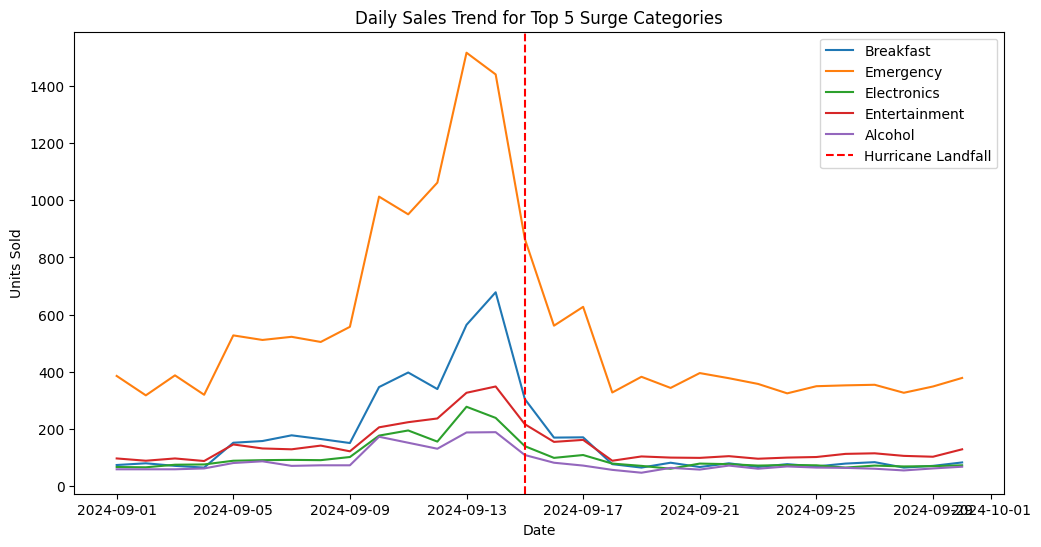

In [24]:
top_categories = top5.index.tolist()

plot_data = daily_category_sales[daily_category_sales["category"].isin(top_categories)]

plt.figure(figsize=(12,6))
for cat in top_categories:
    subset = plot_data[plot_data["category"] == cat]
    plt.plot(subset["date"], subset["quantity"], label=cat)

plt.axvline(landfall, color="red", linestyle="--", label="Hurricane Landfall")
plt.title("Daily Sales Trend for Top 5 Surge Categories")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

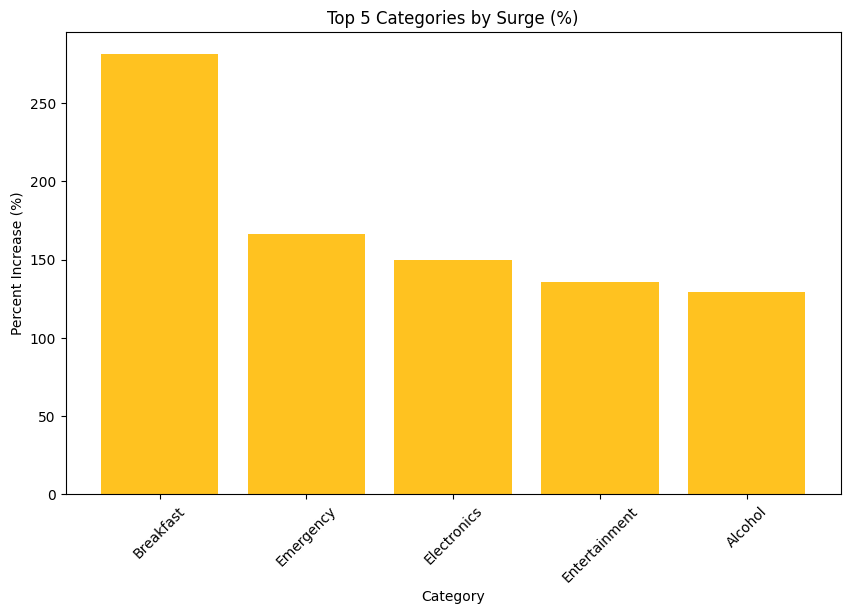

In [25]:
plt.figure(figsize=(10,6))

top5_sorted = top5.sort_values("percent_increase", ascending=False)

plt.bar(top5_sorted.index, top5_sorted["percent_increase"], color="#FFC220")

plt.title("Top 5 Categories by Surge (%)")
plt.xlabel("Category")
plt.ylabel("Percent Increase (%)")

plt.xticks(rotation=45)

plt.show()

#### Analysis

To identify which product categories experienced the largest surge before the hurricane, we compared category sales during the seven days before hurricane landfall to a baseline period one week earlier. After cleaning the transaction dataset by removing duplicates, standardizing timestamps and data types, standardizing and removing redundant category names, and correcting quantity values, we aggregated daily sales by category. We then calculated the percent increase in total units sold between the baseline and surge periods. The results show that several categories experienced significant increases in demand, with breakfast foods, emergency items, electronic supplies, entertainment products, and alcoholic beverages showing the largest growth. Breakfast products and emergency supplies had the percent increase, suggesting that consumers were stocking up on easy-to-store food and emergency supplies before the storm in case they could not leave their houses for an extended period of time.

The line chart shows how sales changed over time and adds more context to those percentages. Sales for most categories start increasing a few days before landfall and peak around September 12 to 14. Emergency supplies clearly have the highest number of units sold, with a sharp spike right before the hurricane, which fits what we would expect as people prepare. Breakfast also rises quickly, likely due to stockpiling food. Alcohol and entertainment do not reach the same heights in total sales, but they still show noticeable increases, which explains their high percentages in the bar chart. Together, the two charts show both how much each category grew and when that growth happened. This pattern indicates that the surge in demand is closely tied to hurricane preparation behavior, as consumers buy both essential supplies and comfort items in anticipation of the storm.

The charts do support the same overall conclusion: demand increases across multiple categories before landfall. However, they emphasize different perspectives. The bar chart highlights relative change, while the line chart shows absolute demand. Together, they give a more complete picture.

### Question 2

In [26]:
# Finding all skus with "pop" in its name
poptarts = transactions[transactions["product_name"].str.contains("pop", case=False)].copy()
print("All Pop-Tarts SKU names")
print(sorted(poptarts["product_name"].unique()))

All Pop-Tarts SKU names
['Pop Tarts - Strawberry', 'Pop-Tarts Strawberry', 'Poptart-Strawberry', 'Strawberry Pop-Tart']


In [27]:
# Sku mapping table
sku_mapping_table = {
    "Pop-Tarts Strawberry" : "Pop-Tarts Strawberry",
    "Poptart-Strawberry": "Pop-Tarts Strawberry",
    "Strawberry Pop-Tart": "Pop-Tarts Strawberry",
    "Pop Tarts - Strawberry": "Pop-Tarts Strawberry"
}
poptarts["product_clean"] = poptarts["product_name"].replace(sku_mapping_table)

before = (poptarts.groupby(["date", "product_name"])["quantity"].sum().reset_index())

after = (poptarts.groupby(["date", "product_clean"])["quantity"].sum().reset_index())

after_total = (after.groupby("date")["quantity"].sum().reset_index(name="true_daily_sales"))

#### Visualizations

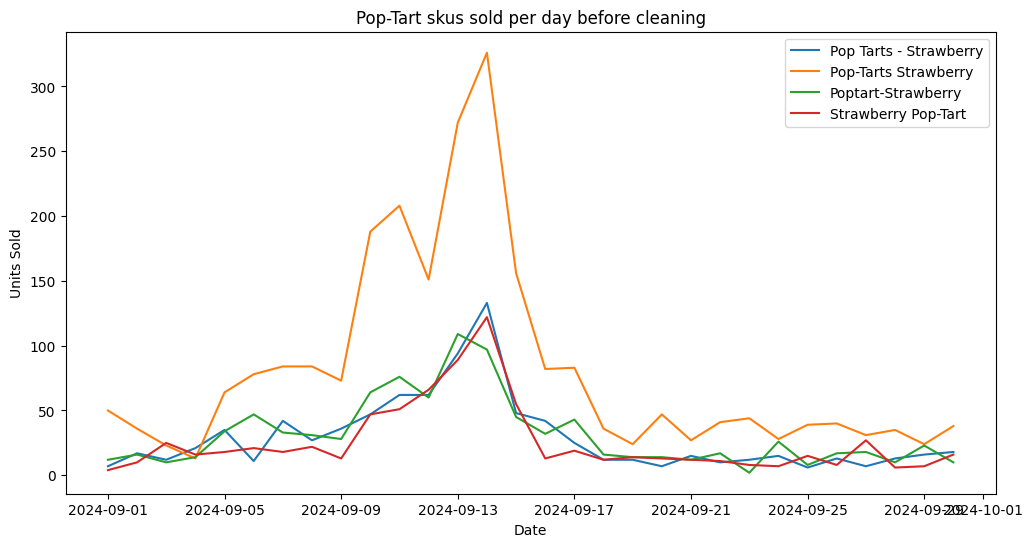

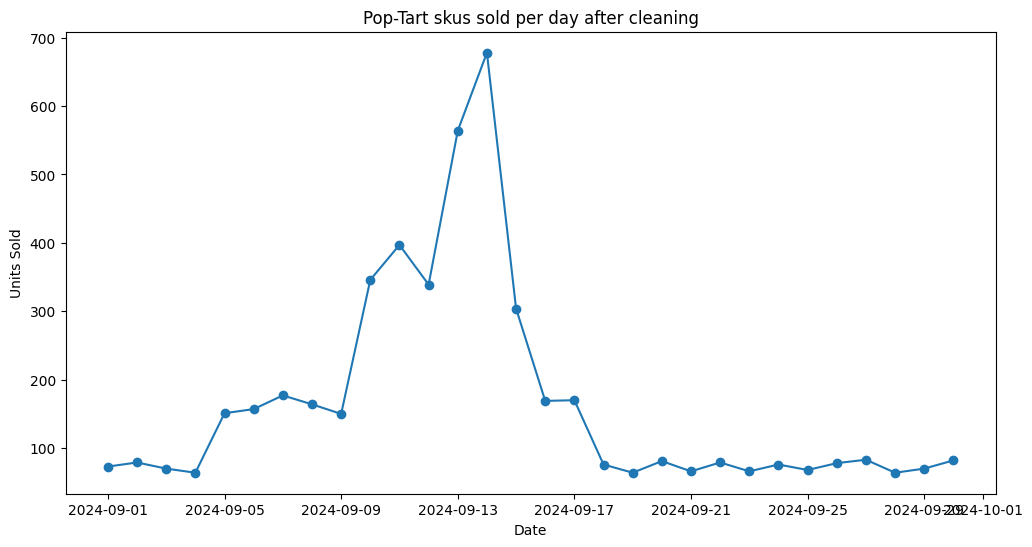

In [28]:
plt.figure(figsize=(12,6))

for skus in before["product_name"].unique():
    rows = before[before["product_name"] == skus]
    plt.plot(rows["date"], rows["quantity"], label=skus)


plt.title("Pop-Tart skus sold per day before cleaning")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(after_total["date"], after_total["true_daily_sales"], marker="o")
plt.title("Pop-Tart skus sold per day after cleaning")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

#### Analysis

As a quick note, the question refers to SKU standardization, but in this dataset the inconsistencies are more apparent in the product_name field rather than the SKU field. The product is the same, but the different SKU's indicate the product being sold by different producers. Since each product_name variant maps cleanly to the same underlying product, we  standardized at the product_name level, which effectively achieves the same goal of unifying fragmented SKUs.

The sales trends before and after consolidation are similar, with a nearly identical uptick and comparable patterns in both the highs and lows of the daily sales data. This is due to one of the SKUs dominating in terms of units sold, leading to its trend being reflected in the consolidated graph. However, all four of the SKUs follow a pattern somewhat similar to the graph for the consolidated data points, with at least one noticeable spike in units sold before landfall. This indicates that sales trends were similar between stores with different SKU names and that it is likely the same underlying Pop-Tart product being sold. The true daily sales volume is much higher, as it is an aggregate of the four SKU names. For instance, the peak of individual skus is around 300 units sold in one day for the most common SKU ("Pop-Tarts Strawberry") and between 100 and 150 for the others. The consolidated view shows a peak of almost 700 units sold in a single day.

From a business persepective, this demonstrates the importance of standarizing SKU names when analyzing sales data. Without consolidation, the fragmented data shows much lower demand, which could lead a business to underestimate the demand for a certain product. This could lead to the business understocking an in demand item, leading to lower sales. Consolidating the data shows the true demand for an item, giving the business a more accurate representation of a product's demand. Additionally, using the fragmented data could lead to smaller trends being overshadowed by larger magnitudes. For instance, if one of the smaller lines had a smaller but important spike on a day no other SKUs had, this trend might not be noted in the large group of lines to analyze, especially in this case where one line is much larger in magnitude overall. Consolidating the SKUs gives these smaller trends a chance to surface in the combined line plot, revealing additional insights relating to product demand.

### Question 3

In [29]:
daily_sales_cat = (
    transactions.groupby(["date", "store_id", "category"])["quantity"]
    .sum()
    .reset_index()
)

# Merge daily sales with weather data and add average temperature
weather_df["airtemp_avg"] = (weather_df["airtemp_max"] + weather_df["airtemp_min"]) / 2
sales_weather = daily_sales_cat.merge(
    weather_df,
    on=["date", "store_id"],
    how="left"
)

categories = sales_weather["category"].unique()
corr_results = []

for cat in categories:
    df_cat = sales_weather[sales_weather["category"] == cat]
    corr_precip = df_cat["quantity"].corr(df_cat["precipitation"])
    corr_wind = df_cat["quantity"].corr(df_cat["wind_speed"])
    corr_pressure = df_cat["quantity"].corr(df_cat["pressure"])
    corr_temp = df_cat["quantity"].corr(df_cat["airtemp_avg"])
    
    corr_results.append({
        "category": cat,
        "corr_precipitation": corr_precip,
        "corr_wind": corr_wind,
        "corr_pressure": corr_pressure,
        "corr_temp": corr_temp
    })

corr_df = pd.DataFrame(corr_results)

#### Visualizations

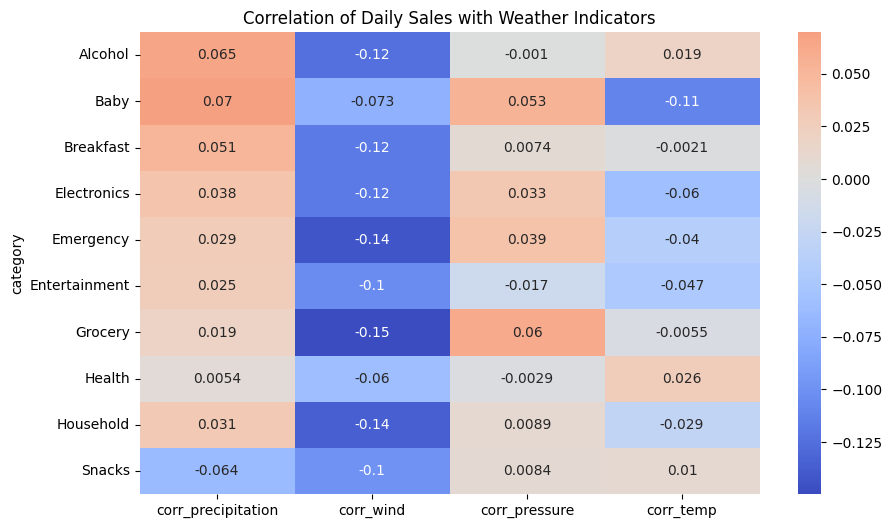

In [30]:
# Heatmap of correlations including average temperature
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_df.set_index("category"),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation of Daily Sales with Weather Indicators")
plt.show()

Top relationship:
Grocery vs corr_wind


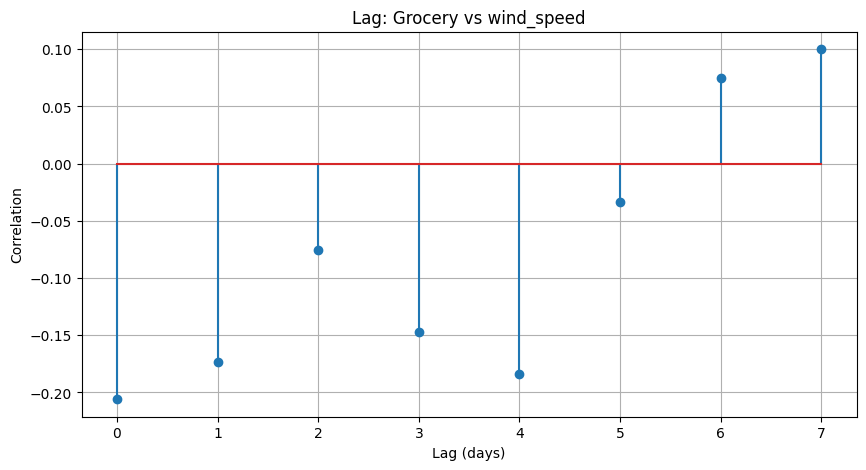

In [31]:
# Pick out strongest correlation
corr_melted = corr_df.melt(
    id_vars="category",
    value_vars=["corr_precipitation", "corr_wind", "corr_pressure", "corr_temp"],
    var_name="weather_var",
    value_name="correlation"
)
top_row = corr_melted.loc[corr_melted["correlation"].abs().idxmax()]
top_category = top_row["category"]
top_weather_var = top_row["weather_var"]

print("Top relationship:")
print(top_category, "vs", top_weather_var)

# Map correlation column to the actual weather column name
weather_map = {
    "corr_precipitation": "precipitation",
    "corr_wind": "wind_speed",
    "corr_pressure": "pressure",
    "corr_temp": "airtemp_avg"
}

# Construct the time series
weather_col = weather_map[top_weather_var]
df_plot = (
    sales_weather[sales_weather["category"] == top_category]
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)
weather_plot = (
    weather_df.groupby("date")[[weather_col]]
    .mean()
    .reset_index()
)

merged = df_plot.merge(weather_plot, on="date", how="inner").sort_values("date")

sales_series = merged["quantity"].values
weather_series = merged[weather_col].values


# Lag analysis plot
max_lag = 7
lags = np.arange(0, max_lag + 1)
cross_corr = []

for lag in lags:
    if lag == 0:
        corr = np.corrcoef(sales_series, weather_series)[0,1]
    else:
        corr = np.corrcoef(sales_series[lag:], weather_series[:-lag])[0,1]
    cross_corr.append(corr)

plt.figure(figsize=(10,5))
plt.stem(lags, cross_corr)
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.title(f"Lag: {top_category} vs {weather_col}")
plt.grid(True)
plt.show()

#### Analysis

These plots combine the cleaned transactions data table with historical weather data pulled from Open-Meteo for each store's location for the month of September 24, including average air temperature (computed from the daily max and min), barometric pressure, precipitation and wind speed. The transactions table was aggregated by store and category to produce the daily units sold per category per store, which was then joined with the pulled weather data based on store ID and date. Correlation coefficients were computed between the daily sales of each category and each weather phenomena per product category to produce a correlation heatmap. 

The heatmap showed that most correlations were very close to 0, suggesting that weather conditions alone are not very strong as a sales predictor. The prevalent pattern is a mild negative relationship between wind speed and sales across many categories (generally between -0.10 and -0.15), suggesting that higher wind speeds may be associated with slight decreases in purchasing activity. However, no category exhibits a particularly strong or meaningful linear relationship with any weather variable.

Finally a lag analysis was performed to determine the relationship between health-related purchasing response and wind speed for various days counts (0 to 7) leading up to the storm. The results show moderately negative correlations at short lags, with the strongest around lag 0 (about -0.21), indicating that higher wind speeds are associated with slightly lower grocery sales on the same day. As the lag increases, correlations weaken and eventually become slightly positive at longer lags (around 6–7 days, ≈ 0.07 to 0.10). This suggests a weak and somewhat delayed relationship between wind conditions and purchasing behavior. While immediate effects tend to be negative, there is slight evidence that increased wind activity may be followed by a small rebound in grocery purchases several days later. However, given the low magnitude of these correlations, the lag effect is not particularly strong, and weather alone does not appear to be a primary driver of sales patterns in this dataset.

### Question 4

In [32]:
daily_store_sales = (
    transactions.groupby(["date", "store_id"])["quantity"]
    .sum()
    .reset_index()
)

landfall = pd.Timestamp("2024-09-15")
surge_start = landfall - pd.Timedelta(days=7)
baseline_start = surge_start - pd.Timedelta(days=7)

baseline_sales = (
    daily_store_sales[
        (daily_store_sales["date"] >= baseline_start) &
        (daily_store_sales["date"] < surge_start)
    ]
    .groupby("store_id")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "baseline_sales"})
)

surge_sales = (
    daily_store_sales[
        (daily_store_sales["date"] >= surge_start) &
        (daily_store_sales["date"] <= landfall)
    ]
    .groupby("store_id")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "surge_sales"})
)

store_comparison = baseline_sales.merge(surge_sales, on="store_id")
store_comparison["percent_increase"] = (
    (store_comparison["surge_sales"] - store_comparison["baseline_sales"])
    / store_comparison["baseline_sales"]
) * 100

# Merge store geographic info
store_comparison = store_comparison.merge(
    stores[["store_id","city","latitude","longitude"]],
    on="store_id",
    how="left"
)

# Define landfall coordinates
landfall_lat = 29.7
landfall_lon = -84.4

# Compute distance to landfall (haversine is best when given latitude and longitude)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians,[lat1,lon1,lat2,lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R*c

store_comparison["distance_km"] = haversine(
    store_comparison["latitude"],
    store_comparison["longitude"],
    landfall_lat,
    landfall_lon
)

# Identify surge outliers (IQR)
Q1 = store_comparison["percent_increase"].quantile(0.25)
Q3 = store_comparison["percent_increase"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
store_comparison["is_outlier"] = (
    (store_comparison["percent_increase"] < lower) |
    (store_comparison["percent_increase"] > upper)
)

#### Visualizations

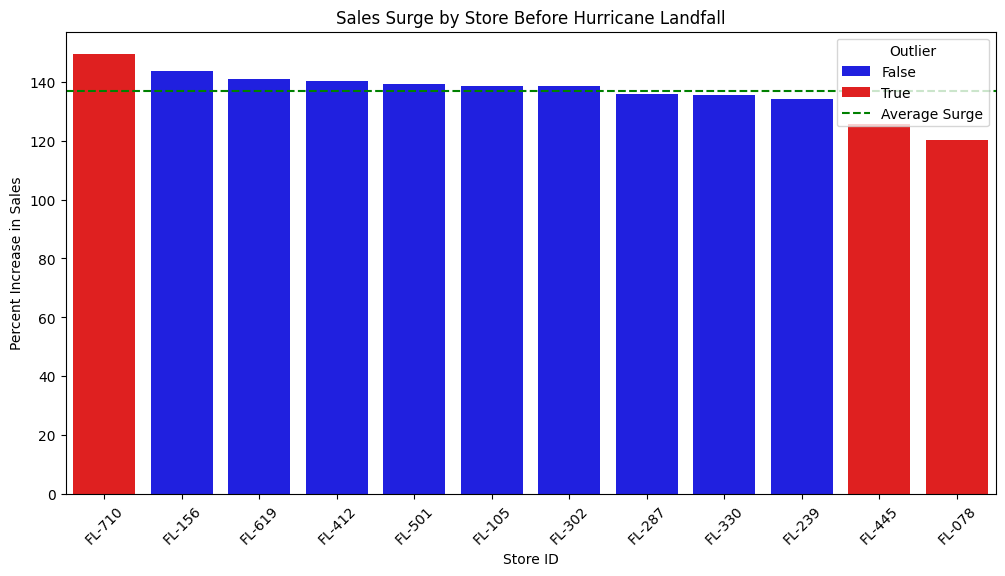

In [33]:
# Surge magnitude
plt.figure(figsize=(12,6))

sorted_data = store_comparison.sort_values("percent_increase", ascending=False)
sns.barplot(
    data=sorted_data,
    x="store_id",
    y="percent_increase",
    hue="is_outlier",
    palette={True: "red", False: "blue"},
    dodge=False
)

plt.axhline(
    store_comparison["percent_increase"].mean(),
    color="green",
    linestyle="--",
    label="Average Surge"
)

plt.title("Sales Surge by Store Before Hurricane Landfall")
plt.xlabel("Store ID")
plt.ylabel("Percent Increase in Sales")
plt.xticks(rotation=45)

plt.legend(title="Outlier")
plt.show()

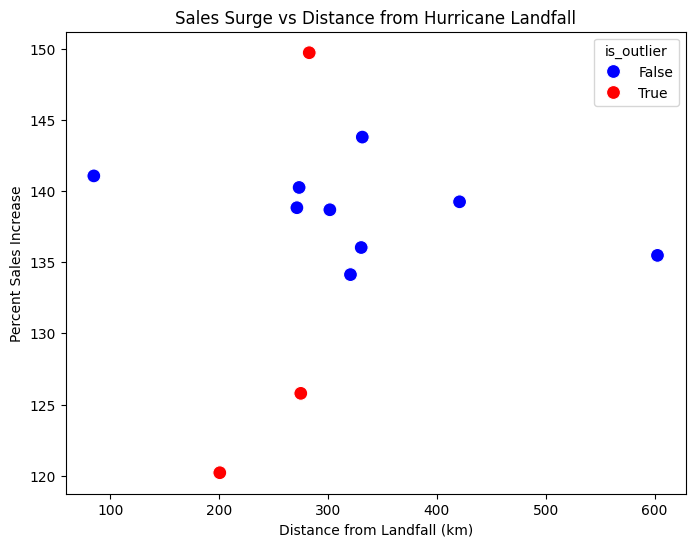

In [34]:
# Distance vs Surge
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=store_comparison,
    x="distance_km",
    y="percent_increase",
    hue="is_outlier",
    palette={True:"red", False:"blue"},
    s=100
)

plt.title("Sales Surge vs Distance from Hurricane Landfall")
plt.xlabel("Distance from Landfall (km)")
plt.ylabel("Percent Sales Increase")

plt.show()

In [35]:
# Identify spike timing
baseline_avg = (
    daily_store_sales[
        (daily_store_sales["date"] >= baseline_start) &
        (daily_store_sales["date"] < surge_start)
    ]
    .groupby("store_id")["quantity"]
    .mean()
)

daily_store_sales = daily_store_sales.merge(
    baseline_avg.rename("baseline_avg"),
    on="store_id"
)

# A 1.3x increase is defined as the "first spike"
daily_store_sales["spike"] = (
    daily_store_sales["quantity"] >
    daily_store_sales["baseline_avg"]*1.3
)

spike_dates = (
    daily_store_sales[daily_store_sales["spike"]]
    .groupby("store_id")["date"]
    .min()
    .reset_index()
)

spike_dates["days_before_landfall"] = (
    landfall - spike_dates["date"]
).dt.days

store_comparison = store_comparison.merge(
    spike_dates[["store_id","days_before_landfall"]],
    on="store_id",
    how="left"
)

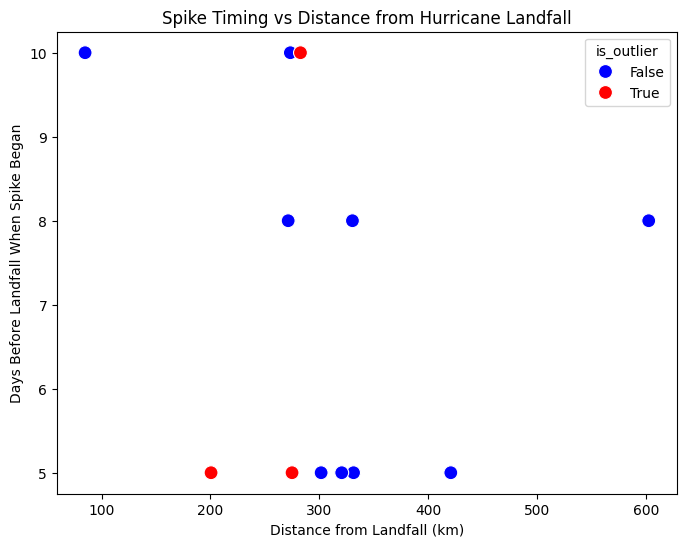

In [36]:
# Distance vs Spike Timing
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=store_comparison,
    x="distance_km",
    y="days_before_landfall",
    hue="is_outlier",
    palette={True:"red", False:"blue"},
    s=100
)

plt.title("Spike Timing vs Distance from Hurricane Landfall")
plt.xlabel("Distance from Landfall (km)")
plt.ylabel("Days Before Landfall When Spike Began")

plt.show()

#### Analysis

To analyze the surge patterns across the different Walmart stores, the transactions data table was aggregated to output the daily sales per store. With September 15, 2024 as the landfall date for the hurricane, the 7 days before this date were establsihed as the surge period. The 7 days before the surge period were labeled the baseline period. The percent increase between baseline and surge sales was computed per store to quantify the surge magnitudes. These results were merged with the stores table to access the latitude and longitude coordinates of each store, which were used to compute each store's distance from the landfall coordinates with haversine distance to see how far each store was from the storm at landfall. This data was then used to generate three visualizations. The first visualization plots each stores percent increase in sales from the baseline period to surge period in descending order with the average percent increase labeled and any outlier stores (identified with the IQR method) appropriately colored red. The next scatterplot compares store distance from the landfall coordinates to percent increase in sales to see if stores closer to the landfall experienced higher surges. For the last scatterplot, we first identified the first day where each store's daily sales exceeded 130% of the baseline period average and labeled it as the start of the surge. The number of days between this start and the landfall was plotted with the store's distance from the landfall to see whether stores closer to the landfall location had earlier starting surges. 

Looking at the first visualization, we now see that FL-710 (Pensacola) experienced the largest percent increase in sales (about 150%%), followed by FL-156 (Daytona Beach) and FL-619 (Tallahassee), all showing surges above 140%. The percent increases are generally consistent across stores, generally falling within a narrow range of about 120% to 150%, indicating that most locations experienced a similar surge magnitude leading up to landfall. A few stores were identified as outliers. Specifically, FL-710 (Pensacola) appears as a high-end outlier with the strongest surge, while FL-445 (St. Petersburg) and FL-078 (Gainesville) are also flagged as outliers, though their increases are comparatively lower (about 125% and 120%). This suggests that while most stores follow a consistent surge pattern, there are a few locations that slightly deviate from the typical distribution of surges, either experiencing unusually strong or relatively weaker increases in demand. In the second visualization, we don't really see any clear relationship between landfall distance and surge magnitude when considering all the points. Most stores seem to be 200 to 400 km from the landfall yet range from 120% to 150% in terms of surge magnitude. Then, with two stores around 100km and 600km, respectively from the landfall location having similar percent increases in sales at around 140%, it is clear that there isn't an obviously linear relationship here. However, removing the three outliers mentioned before reveals a slightly negative trend, where stores further from landfall seem to have slightly less percent increases in sales. Whether including outliers or not, the third visualization doesn't really show any clear relationship between spike start and landfall distance. This indicates that the proximity of a store to the storm itself, particularly during landfall, does not seem to have much of an impact on the timing of purchasing spikes. Overall, these results suggest that while all stores experience similar surge behavior ahead of the hurricane, proximity to the storm’s path does not strongly influence either the magnitude or timing of demand spikes, indicating that anticipation-based purchasing is relatively uniform across regions.

### Question 5

In [37]:
conn_sqlite = sqlite3.connect('/kaggle/input/datasets/kevint135/ds2002-walmart-data-midterm-project/inventory_and_sales.db')


# Entertainment daily sales
q_sales = """
SELECT date, store_id, category, total_units, total_revenue
FROM daily_sales_summary
WHERE category = 'Entertainment'
ORDER BY date
"""
daily_sales_sql = pd.read_sql(q_sales, conn_sqlite)

# Inventory levels for all SKU's
q_inventory = """
SELECT date, store_id, sku, units_on_hand, units_on_order, reorder_point
FROM inventory_levels
"""
inventory_sql = pd.read_sql(q_inventory, conn_sqlite)

In [38]:
# Cleaning the data pulled from the queries
daily_sales_sql.columns = (
    daily_sales_sql.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

daily_sales_sql["store_id"] = (
    daily_sales_sql["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Standardize store_id as in previous tables
daily_sales_sql["store_id"] = daily_sales_sql["store_id"].str.replace(
    r"^FL(\d+)", r"FL-\1", regex=True
)

daily_sales_sql["date"] = pd.to_datetime(daily_sales_sql["date"], errors="coerce").dt.date

daily_sales_sql["total_units"] = pd.to_numeric(daily_sales_sql["total_units"], errors="coerce").round().astype("Int64")
daily_sales_sql["total_revenue"] = pd.to_numeric(daily_sales_sql["total_revenue"], errors="coerce")
daily_sales_sql = daily_sales_sql[
    (daily_sales_sql["total_units"] >= 0) &
    (daily_sales_sql["total_revenue"] >= 0)
]

daily_sales_sql = (
    daily_sales_sql
    .groupby(["date", "store_id", "category"], as_index=False)
    .agg(
        total_units=("total_units", "sum"),
        total_revenue=("total_revenue", "sum")
    )
)

daily_sales_sql = daily_sales_sql.dropna(subset=["date"]).reset_index(drop=True)

inventory_sql.columns = (
    inventory_sql.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

inventory_sql["store_id"] = (
    inventory_sql["store_id"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

inventory_sql["store_id"] = inventory_sql["store_id"].str.replace(
    r"^FL(\d+)", r"FL-\1", regex=True
)

inventory_sql["date"] = pd.to_datetime(inventory_sql["date"], errors="coerce").dt.date

inventory_sql["sku"] = (
    inventory_sql["sku"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-")
)

# Keep only valid SKUs
valid_skus = set(products["sku"])
inventory_sql = inventory_sql[inventory_sql["sku"].isin(valid_skus)]

inventory_sql["units_on_hand"] = pd.to_numeric(inventory_sql["units_on_hand"], errors="coerce")
inventory_sql["units_on_order"] = pd.to_numeric(inventory_sql["units_on_order"], errors="coerce")
inventory_sql["reorder_point"] = pd.to_numeric(inventory_sql["reorder_point"], errors="coerce")

inventory_sql["units_on_order"] = inventory_sql["units_on_order"].fillna(0)

inventory_sql = inventory_sql[
    (inventory_sql["units_on_hand"] >= 0) &
    (inventory_sql["units_on_order"] >= 0) &
    (inventory_sql["reorder_point"] >= 0)
]

inventory_sql = (
    inventory_sql
    .groupby(["date", "store_id", "sku"], as_index=False)
    .agg(
        units_on_hand=("units_on_hand", "mean"),
        units_on_order=("units_on_order", "mean"),
        reorder_point=("reorder_point", "mean")
    )
)

inventory_sql["units_on_hand"] = inventory_sql["units_on_hand"].round().astype(int)
inventory_sql["units_on_order"] = inventory_sql["units_on_order"].round().astype(int)
inventory_sql["reorder_point"] = inventory_sql["reorder_point"].round().astype(int)

inventory_sql = inventory_sql.dropna(subset=["date"]).reset_index(drop=True)

#### Visualizations

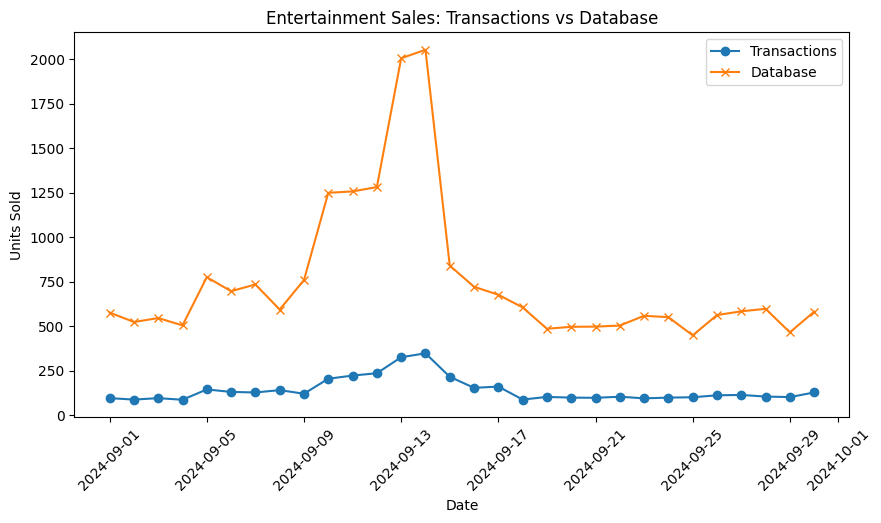

In [39]:
# Compare with transactions table
txn_ent = (
    transactions[transactions["category"] == "Entertainment"]
    .groupby("date")["quantity"]
    .sum()
    .reset_index(name="txn_units")
)

db_ent = (
    daily_sales_sql.groupby("date")["total_units"]
    .sum()
    .reset_index(name="db_units")
)

txn_ent["date"] = pd.to_datetime(txn_ent["date"])
db_ent["date"] = pd.to_datetime(db_ent["date"])
comparison = txn_ent.merge(db_ent, on="date", how="inner")
comparison["difference"] = comparison["db_units"] - comparison["txn_units"]
comparison["ratio"] = comparison["db_units"] / comparison["txn_units"]

# DB vs Transactions Visualization
plt.figure(figsize=(10,5))
plt.plot(comparison["date"], comparison["txn_units"], marker="o", label="Transactions")
plt.plot(comparison["date"], comparison["db_units"], marker="x", label="Database")
plt.title("Entertainment Sales: Transactions vs Database")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

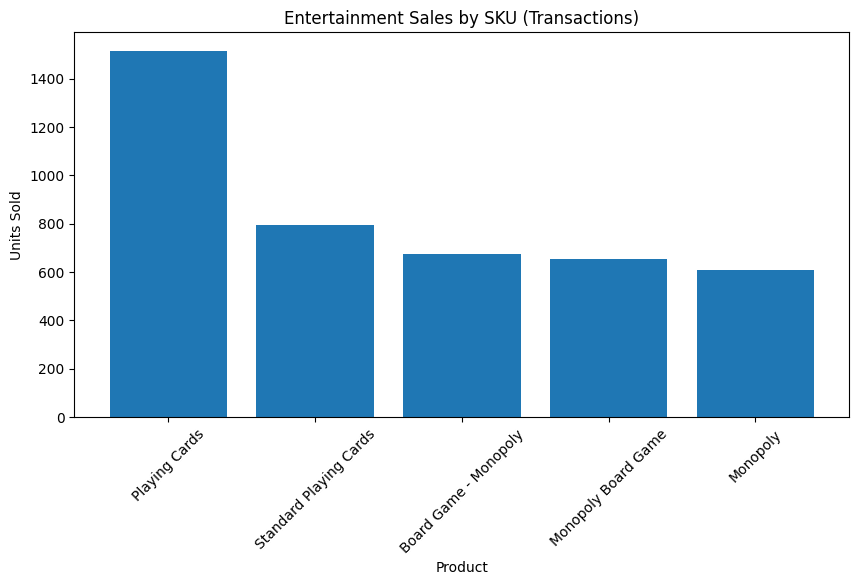

In [40]:
# Units sold per SKU in Entertainment
bg_skus = (
    transactions[transactions["category"] == "Entertainment"]
    .groupby("product_name")["quantity"]
    .sum()
    .reset_index()
    .sort_values("quantity", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(bg_skus["product_name"], bg_skus["quantity"])
plt.title("Entertainment Sales by SKU (Transactions)")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

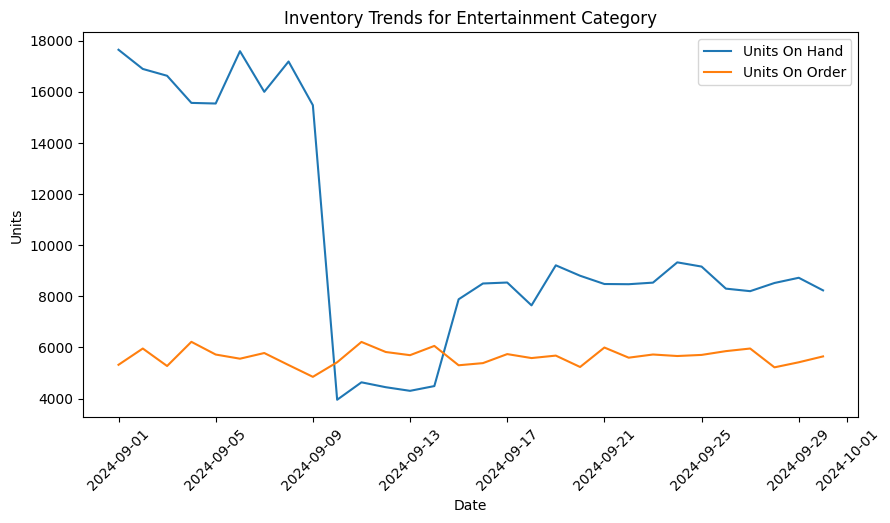

In [41]:
# Inventory supply-demand plot
inventory_summary = (
    inventory_sql.groupby("date")[["units_on_hand", "units_on_order"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(inventory_summary["date"], inventory_summary["units_on_hand"], label="Units On Hand")
plt.plot(inventory_summary["date"], inventory_summary["units_on_order"], label="Units On Order")
plt.title("Inventory Trends for Entertainment Category")
plt.xlabel("Date")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.legend()
plt.show()

conn_sqlite.close()

#### Analysis

To investigate whether the Entertainment sales surge reflects real demand or a data artifact, we queried the daily_sales_summary and inventory_levels tables from the SQLite database. Since the database is read-only, we cleaned the queried data within the notebook before analysis, standardizing fields like store_id, date, and numeric columns. We then aggregated daily Entertainment sales from both the database and the transactions dataset and compared their total units sold in a line chart. Then, we aggregated Entertainment sales by SKU from the transactions data and plotted a bar chart of units sold per product. Finally, we analyzed inventory trends by aggregating total units on hand and units on order over time and visualizing them to see how inventory responded to sales patterns.

The 250% increase in board games/entertainment sales appears to be driven mostly by data artifacts rather than an actual surge in demand. From the transactions data, daily Entertainment sales are usually between about 90 and 150 units, with a temporary peak around 350 units in the days immediately before landfall. While this is a somewhat noticeable spike in units sold, it is still moderate and short-lived. The database, on the other hand, has much higher values, ranging from about 500 to over 2000 units at the peaks before landfall. There is a gap where the database reports substantially higher sales than the transactions table consistently. This suggests that the database is aggregating a broader set of products under the “Entertainment” category, inflating the surge. The SKU-level breakdown further supports this. The highest-selling items include Playing Cards (about 1500 units) and Standard Playing Cards (about 800 units), alongside multiple variations of Monopoly (each around 600–700 units). This indicates that the category is not limited to board games and has different SKUs representing the same underlying items. As a result, the observed increase is not solely due to board game demand, but rather due to multiple product types and duplicates. Inventory trends also do not strongly support a true demand spike. Units on hand fluctuate significantly, dropping sharply from around 15,000–17,000 units to under 4,000 units just before landfall, but then quickly recover to around 7,000–9,000 units afterward. Units on order, however, remain stable between 5,000 and 6,000 units without a clear increase in response to the surge period. If the demand increase were truly 250%, a more sustained depletion of inventory matched with a spike in orders would have been observed. The mismatch between transactions and database sales, the mixed and fragmented SKU composition, and the lack of a strong inventory response all indicate that the reported 250% increase is an overestimate caused by category lumping and aggregation effects rather than a true surge in board game demand. Thus, Walmart should not significantly increase board game inventory for future storms based solely on this spike.

## Reflection

### Question 1 - Data Quality Impact

One major data quality issue we ran into was inconsistent category naming. In the raw dataset, the same type of product appeared under slightly different labels, such as “Emergency Supplies” versus “Emergency” or “Alcoholic Beverages” versus “Alcohol.” If left uncorrected, this would split the data across multiple categories and make each one look smaller than it actually is. To fix this, we created a mapping to standardize category names before doing any grouping or analysis.
This cleaning step had a clear impact on the results. After standardizing categories, Emergency shows 1816 units sold during the surge period compared to 771 in the baseline, which is about a 136% increase. Alcohol increases from 471 to 1080, which leads to a 130% jump. These numbers reflect the full demand within each category. If the categories had remained inconsistent, those totals would have been spread across multiple labels, lowering both the baseline and surge values in uneven ways. That could have changed the percent increase calculation and even the ranking of the top five categories.
This issue also affects how the visualizations are interpreted. The bar chart relies directly on percent increase, so fragmented categories would make some appear less important than they really are. The line chart would also look flatter or more scattered because the true spikes would be divided across multiple lines. Therefore, this shows that even small inconsistencies in labeling can distort both the numbers and the story the data is telling.

### Question 2 - ETL Trade-offs

One key decision we made during our data analysis was how we pulled and joined the weather data from Open-Meteo. The two most important decisions we made were to pull daily weather data and to pull data for each store based on their latitude and longitude coordinates. This allowed us to align the weather data with daily sales per store and per category easily, while also ensuring each store had localized weather data accurate to its location. This made the correlation and store-level analysis results in questions 3 and 4 much more reliable. An alternative approach we could have taken would be to pull hourly weather data from a single general coordinate that would apply to all the stores. The hourly data could allow for more fine-grained analysis (i.e. specific hours in the day where panic buying is more common), but it is likely that the hourly sales values would be more sparse and noisy, making patterns harder to detect. Also, pulling weather data from a single set of coordinates would limit our store-level analysis, as differences in weather patterns between the stores across Florida would not be reflected, distorting our results. It would also remove any geographic variation in the data and prevent us from analyzing distance-based surge and spike effects like we did in question 4.


### Question 3 - Pipeline Trust

We would definitely agree with the Walmart CDO, as issues of uncleaned data showing different results are apparent throughout our analysis. Grouping redundant categories together ensured consistent results, however not doing this, for instance leaving "Baby" and "Baby Products" as separate categories, would lead to incomplete category-specific insights when looking at weather correlations, units sold and much more, as such groups, which should be combined, are as a result underrepresented in their metrics. Additionally, the store-level surge results and distance calculations only worked because the store_id values were standardized across both the transactions and stores datasets. If those IDs were inconsistent, the merge would have failed or dropped rows, which would completely distort the percent increase calculations and the geographic analysis.

One of the most fragile parts of our data pipeline that we  didn't catch at first was the timestamp parsing and standardization, specifically in the transactions table, where there were many variants of conveying the date and time of a transaction (different orders, extra characters, etc.). Standard parsing methods could not deal with all of these, resulting in nearly 90% of the transactions data being dropped. We instead switched to a built-in Python date parse in the dateutil library that allowed us to properly parse and preserve nearly all the data, which made our analysis more robust and also changed some correlations and general trends compared to when a limited portion of the data was used. Another fragile part of the pipeline was joining multiple datasets, especially when combining transaction data with store location data. This step depended on several earlier cleaning decisions, including fixing store_id formats and correcting missing latitude and longitude values (like for Tallahassee). If even one of those steps was done incorrectly, the distance calculations using the haversine formula would be wrong, and the scatterplots comparing surge to distance would be misleading. This would then affect the final conclusion that distance from landfall does not strongly impact surge behavior. Another fragile point was how the surge and baseline periods were defined. The analysis assumes that these date ranges are correct and consistent across all stores. If timestamps were misparsed or if timezones were inconsistent, stores could be placed in the wrong period, which would skew both the percent increase values and the spike timing analysis.

### Question 4 - Business vs Data

We weighed the statistical evidence against business risk by focusing on data reliability rather than just the size of the reported increase. The database showed a large surge in Entertainment sales, but the transactions data showed a much smaller and shorter-lived spike. The SKU breakdown also revealed that the category included mixed products like playing cards and multiple versions of the same games, which inflated totals. Because of these inconsistencies, we treated the 250% increase as overstated and did not fully trust it as a true signal of demand. From a business perspective, this led to a cautious decision. Overstocking board games based on inflated data could result in excess inventory and unnecessary costs. The inventory trends supported this, since units on order stayed relatively stable and did not reflect a strong response to a true demand spike. With more time or better data, the decision could be refined. Cleaner SKU mapping and a clearer separation of product types would help isolate actual board game demand. With that, we might identify a smaller but real increase in certain items and recommend a modest inventory adjustment rather than ignoring the signal entirely.

### Question 5 - Team Collaboration

The five questions for the assignment were distributed among the three of us. Inmar worked on all of question 1 and data cleaning. Arjun worked on some of the data cleaning, Questions 3 and 4, and also added more visualizations to Question 5. I (Kevin) worked on all of Question 2 and Question 5. This was the most effective approach for us since we could work in parallel on different sections while still contributing to the overall pipeline. If we had another week, we would spend more time cross-checking each other's work to get a better understanding of how the five questions relate to each other. With more time, we could further explore the observed trends and validate each other's findings. For instance, we could pull data on more weather phenomena from the Open-Meteo API to investigate the correlation between category-specific daily sales and more weather features. The most valuable contributing from Inmar was establishing a clean dataset that ensured that our data analysis would be reliable. Arjun's work on the weather API and the visualizations that helped connect the weather data to the sales data made the trends easier to interpret. I (Kevin) was mainly responsible for analyzing the relationships in Questions 2 and 5, examining the correlations between sales and other factors, to finally create a recommendation for the final analysis. 